### 0. General imports

In [1]:
# Enable autoreloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Add the repo root (two levels up from this notebook) to sys.path
sys.path.insert(0, os.path.abspath("../../"))

/var/folders/5w/ywxgfztj1gz9l25vwcl_sqm80000gn/T/ipykernel_38579/921967279.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### 1. Imports, data-loading and cleaning

#### - Import all the necessary packages.
#### - Load the mushroom dataset.
#### - Preprocess for missing values.

In [2]:
# ===== Imports =====

from courselib.utils.loaders import load_or_download_csv
from courselib.utils.splits import train_test_split
from courselib.utils.metrics import binary_accuracy
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from courselib.models.linear_models import RidgeClassifier
from courselib.models.svm import LinearSVM, BinaryKernelSVM
from courselib.optimizers import GDOptimizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
%matplotlib inline

# === Load and preprocess data ===

filename = 'mushroom_data.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'

df = load_or_download_csv(filename, url)

df.columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]

# Replace ? with missing, to be processed better
df.replace('?', 'missing', inplace=True) 

Loading from local `mushroom_data.csv`...


### 2. Visualize the data 

#### To get a better intuition for importance of certain categories: visualize the correlation between odor and edibility of a mushroom. 

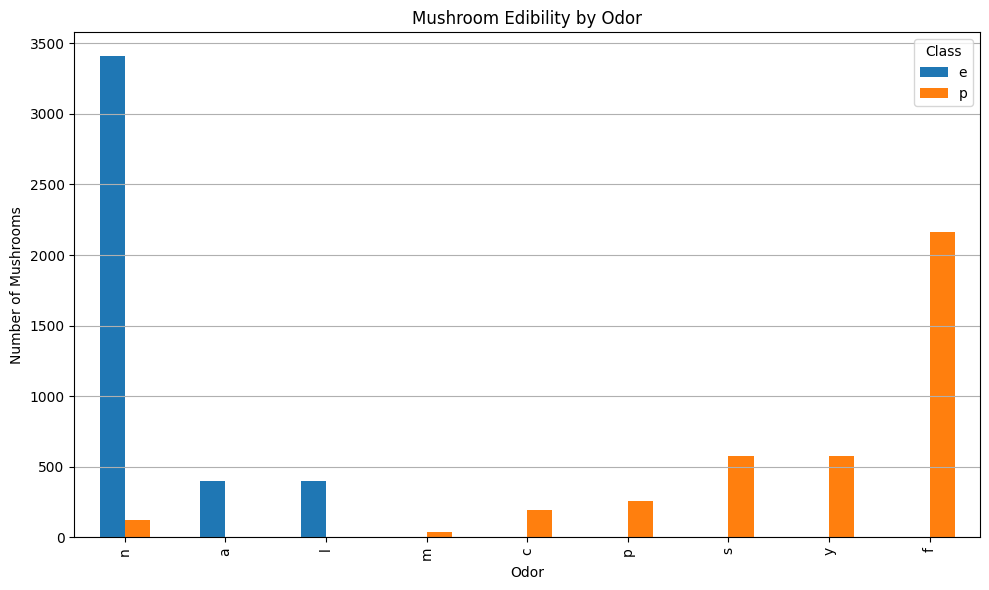

In [3]:
# === Visualize the dataset ===

odor_class_counts = df.groupby(['odor', 'class']).size().unstack(fill_value=0)

sort_key = odor_class_counts['e'].apply(lambda x: -x if x > 0 else None)
odor_class_counts['sort_order'] = sort_key.fillna(odor_class_counts['p'])
odor_class_counts_sorted = odor_class_counts.sort_values(by='sort_order', ascending=[True])
odor_class_counts_sorted = odor_class_counts_sorted.drop(columns='sort_order')

# Plot
odor_class_counts_sorted.plot(kind='bar', figsize=(10, 6), title='Mushroom Edibility by Odor')

plt.xlabel('Odor')
plt.ylabel('Number of Mushrooms')
plt.legend(title='Class')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### 3. Study 3 encoding strategies

#### - Define one-hot, ordinal, frequncy encodings.
#### - Define functions to evaluate the sparsity and to plot the PCA-features.

Encoding: One-hot
 - Test accuracy: 99.8923
 - Coefficients zeroed out: 98 / 117 (83.76%)



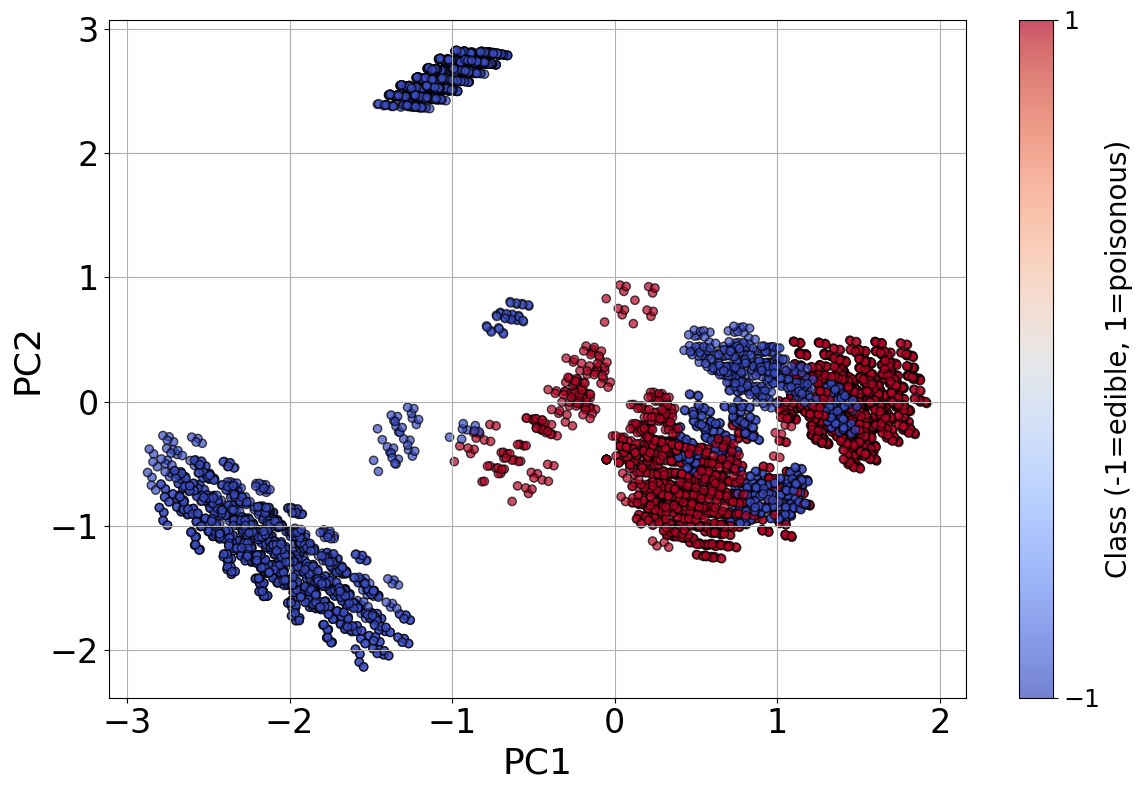

Encoding: Ordinal
 - Test accuracy: 96.3835
 - Coefficients zeroed out: 2 / 22 (9.09%)



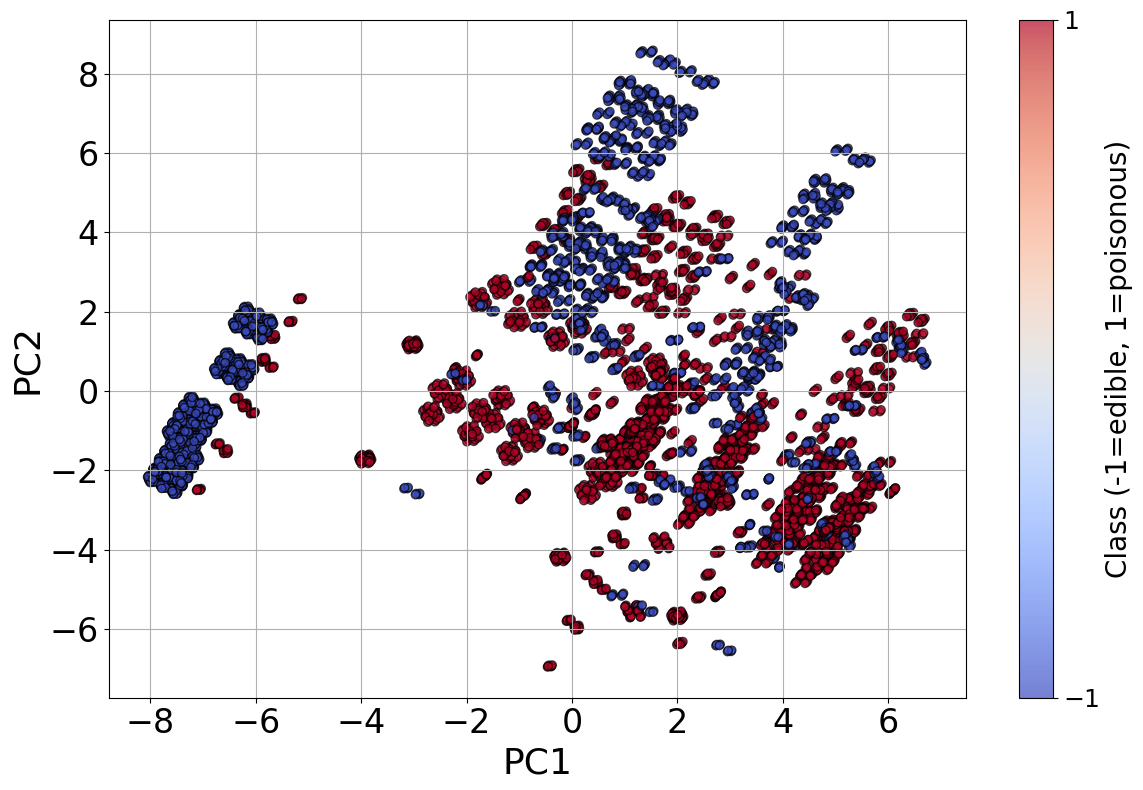

Encoding: Frequency
 - Test accuracy: 99.1074
 - Coefficients zeroed out: 8 / 22 (36.36%)



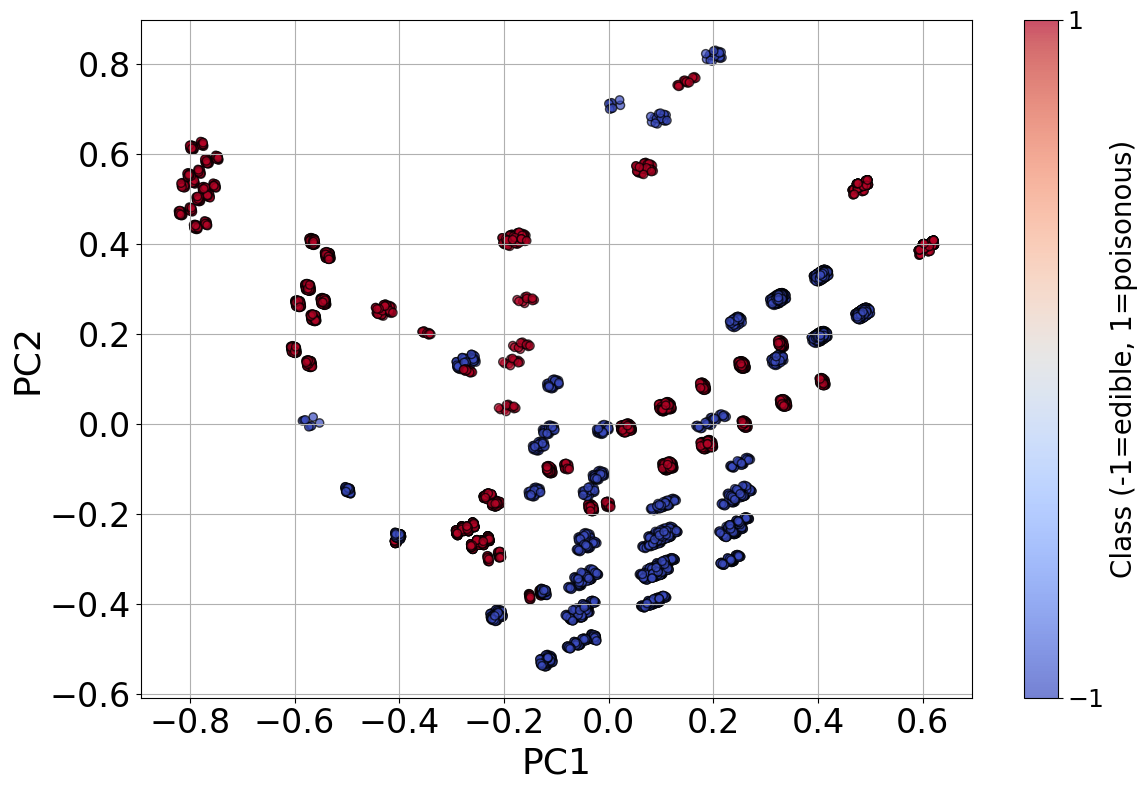

In [4]:
# ===== Implement different encoding, compare them, using Lasso regression =====

def evaluate_sparsity(features, y, name, C=1.0):

    features = features.copy()
    features['class'] = y

    X, Y, X_train, Y_train, X_test, Y_test = train_test_split(
        features, training_data_fraction=0.2, class_column_name='class'
    )

    # Logistic Regression with L1 penalty
    clf = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    clf.fit(X_train, Y_train)

    Y_pred = clf.predict(X_test)
    acc = binary_accuracy(Y_test, Y_pred)

    coef = clf.coef_.flatten()
    num_zero = np.sum(coef == 0)
    total = coef.size
    sparsity_pct = 100 * num_zero / total  

    print(f"Encoding: {name}")
    print(f" - Test accuracy: {acc:.4f}")
    print(f" - Coefficients zeroed out: {num_zero} / {total} ({sparsity_pct:.2f}%)")
    print("")

def plot_pca_features(X_encoded, y, encoding_name):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_encoded)

    plt.figure(figsize=(12,8)) 
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
    cbar = plt.colorbar(scatter, ticks=[-1, 1])
    cbar.set_label('Class (-1=edible, 1=poisonous)', fontsize=20)
    cbar.ax.tick_params(labelsize=18)

    plt.xlabel("PC1", fontsize=26)
    plt.ylabel("PC2", fontsize=26)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 1. One-hot encoding
X_copy = df.drop(columns='class')
X_one_hot = pd.get_dummies(X_copy) # one-hot encode the data

# 2. Ordinal encoding
y = df['class'].map({'e': 1, 'p': -1})  # edible = 1, poisonous = -1
ordinal_encoder = OrdinalEncoder()
X_encoded = ordinal_encoder.fit_transform(X_copy)
X_encoded_df = pd.DataFrame(X_encoded, columns=X_copy.columns)

# 3. Frequency encoding
X_freq_encoded = X_copy.copy()

for col in X_freq_encoded.columns:
    freq = X_freq_encoded[col].value_counts(normalize=True)
    X_freq_encoded[col] = X_freq_encoded[col].map(freq)

# Analyze the encoding methods

encoded_features = {
    "One-hot": X_one_hot,
    "Ordinal": X_encoded_df,
    "Frequency": X_freq_encoded
}

for encoding_name, features_df in encoded_features.items():
    evaluate_sparsity(features_df, y, encoding_name)
    
    # Add label column to features
    features = features_df.copy()
    features['class'] = y.values

    plot_pca_features(features_df.values, y, encoding_name)

### 4. Ridge classification and linear SVM

#### Perform a 5-fold training of Ridge- and linear SVM models for various encodings, plot the accuracies and loss function values.


Overall summary table across all encodings:
 Encoding                Model Mean Accuracy
Frequency           Linear SVM         55.95
          Ridge classification         92.93
  One-hot           Linear SVM         98.02
          Ridge classification         97.94
  Ordinal           Linear SVM         59.07
          Ridge classification         89.41


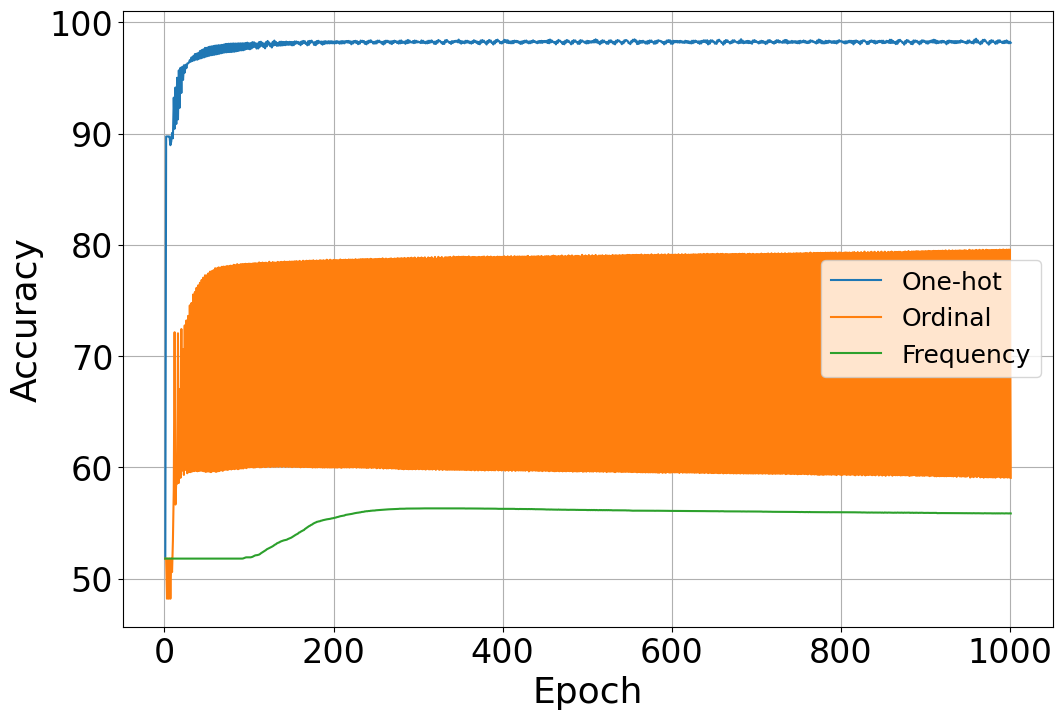

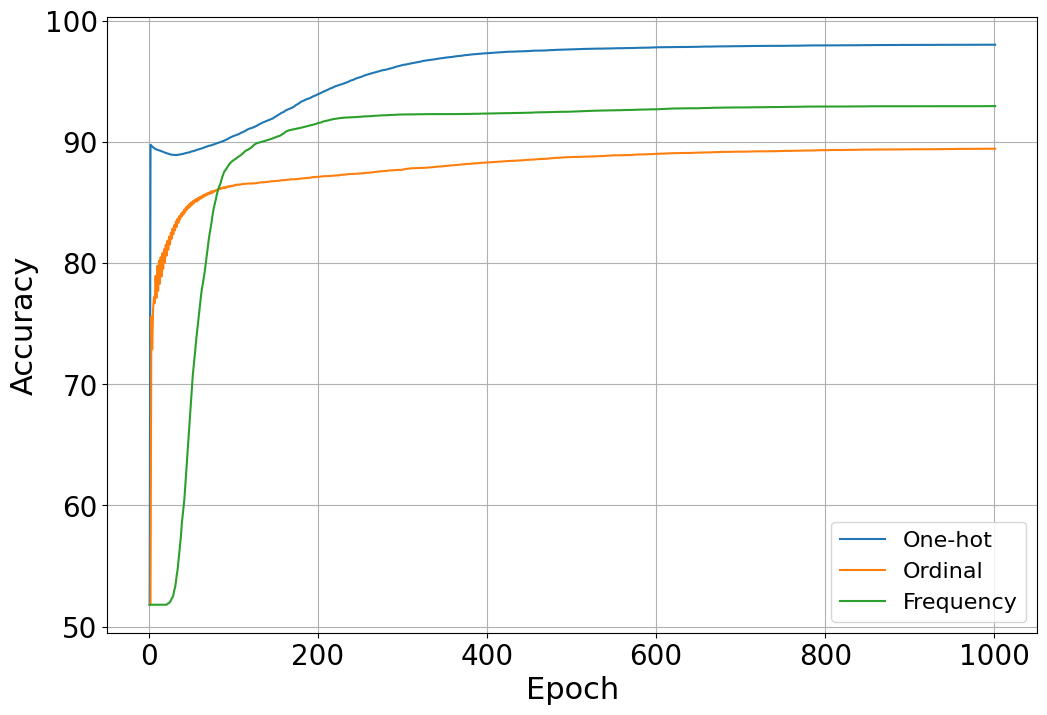

In [ ]:
# ===== Trains Ridge classification and linear SVM models =====

k_folds = 5 # cross-validation

all_results_summary = []
svm_learning_curves = {}
ridge_learning_curves = {} 

for encoding_name, features_df in encoded_features.items():
    features = features_df.copy()
    features['class'] = y.values
    X = features.drop(columns=['class']).values
    Y = features['class'].values

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results_summary = {
        "Ridge classification": [],
        "Linear SVM": []
    }

    svm_epoch_accuracies = []
    ridge_epoch_accuracies = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        w_init = [0] * X.shape[1]
        b_init = 0
        optimizer = GDOptimizer(learning_rate=1e-2)

        models = {
            "Ridge classification": RidgeClassifier(w_init, b_init, optimizer),
            "Linear SVM": LinearSVM(w_init, b_init, optimizer)
        }

        for name, model in models.items():
            if name == "Ridge classification":
                metrics_dict = {
                    "accuracy": lambda y_pred, y_true: binary_accuracy(y_pred, y_true)
                }
                metrics_history = model.fit(
                    X_train, Y_train, num_epochs=1000, batch_size=len(X_train),
                    compute_metrics=True, metrics_dict=metrics_dict
                )
                ridge_epoch_accuracies.append(metrics_history["accuracy"])
            else:
                metrics_dict = {
                    "accuracy": lambda y_pred, y_true: binary_accuracy(y_pred, y_true),
                    "loss": lambda y_pred, y_true: np.mean(np.maximum(0, 1 - y_true * y_pred))
                }
                metrics_history = model.fit(
                    X_train, Y_train, num_epochs=1000, batch_size=len(X_train),
                    compute_metrics=True, metrics_dict=metrics_dict
                )
                svm_epoch_accuracies.append(metrics_history["accuracy"])

            acc = binary_accuracy(model.decision_function(X_val), Y_val, class_labels=[-1, 1])
            results_summary[name].append(acc)

    for name, scores in results_summary.items():
        mean_acc = np.mean(scores)
        all_results_summary.append({
            "Encoding": encoding_name,
            "Model": name,
            "Mean Accuracy": f"{mean_acc:.2f}"
        })

    if svm_epoch_accuracies:
        svm_epoch_accuracies = np.array(svm_epoch_accuracies)
        svm_learning_curves[encoding_name] = np.mean(svm_epoch_accuracies, axis=0)
    if ridge_epoch_accuracies:
        ridge_epoch_accuracies = np.array(ridge_epoch_accuracies)
        ridge_learning_curves[encoding_name] = np.mean(ridge_epoch_accuracies, axis=0)

# Format and print summary table
df_all_results = pd.DataFrame(all_results_summary)
df_all_results = df_all_results.sort_values(by=["Encoding", "Model"])
df_all_results['Encoding'] = df_all_results['Encoding'].mask(df_all_results['Encoding'].duplicated(), '')

print("\nOverall summary table across all encodings:")
print(df_all_results.to_string(index=False))

# Plot Linear SVM accuracy development
plt.figure(figsize=(12,8))
for encoding_name, mean_accuracy in svm_learning_curves.items():
    plt.plot(range(1, len(mean_accuracy)+1), mean_accuracy, label=f"{encoding_name}")
plt.xlabel('Epoch', fontsize=22)
plt.ylabel('Accuracy', fontsize=22)
plt.legend(fontsize=16)
plt.grid(True)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

# Plot Ridge classification accuracy development
plt.figure(figsize=(12,8))
for encoding_name, mean_accuracy in ridge_learning_curves.items():
    plt.plot(range(1, len(mean_accuracy)+1), mean_accuracy, label=f"{encoding_name}")
plt.xlabel('Epoch', fontsize=22)
plt.ylabel('Accuracy', fontsize=22)
plt.legend(fontsize=16)
plt.grid(True)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

### 5. Addition: Kernel RBF parameter comparison

#### Using one-hot encoded data, study the complexity/accuracy trade-off of the kernel SVM method, in dependence on the chosen hyperparameter values.

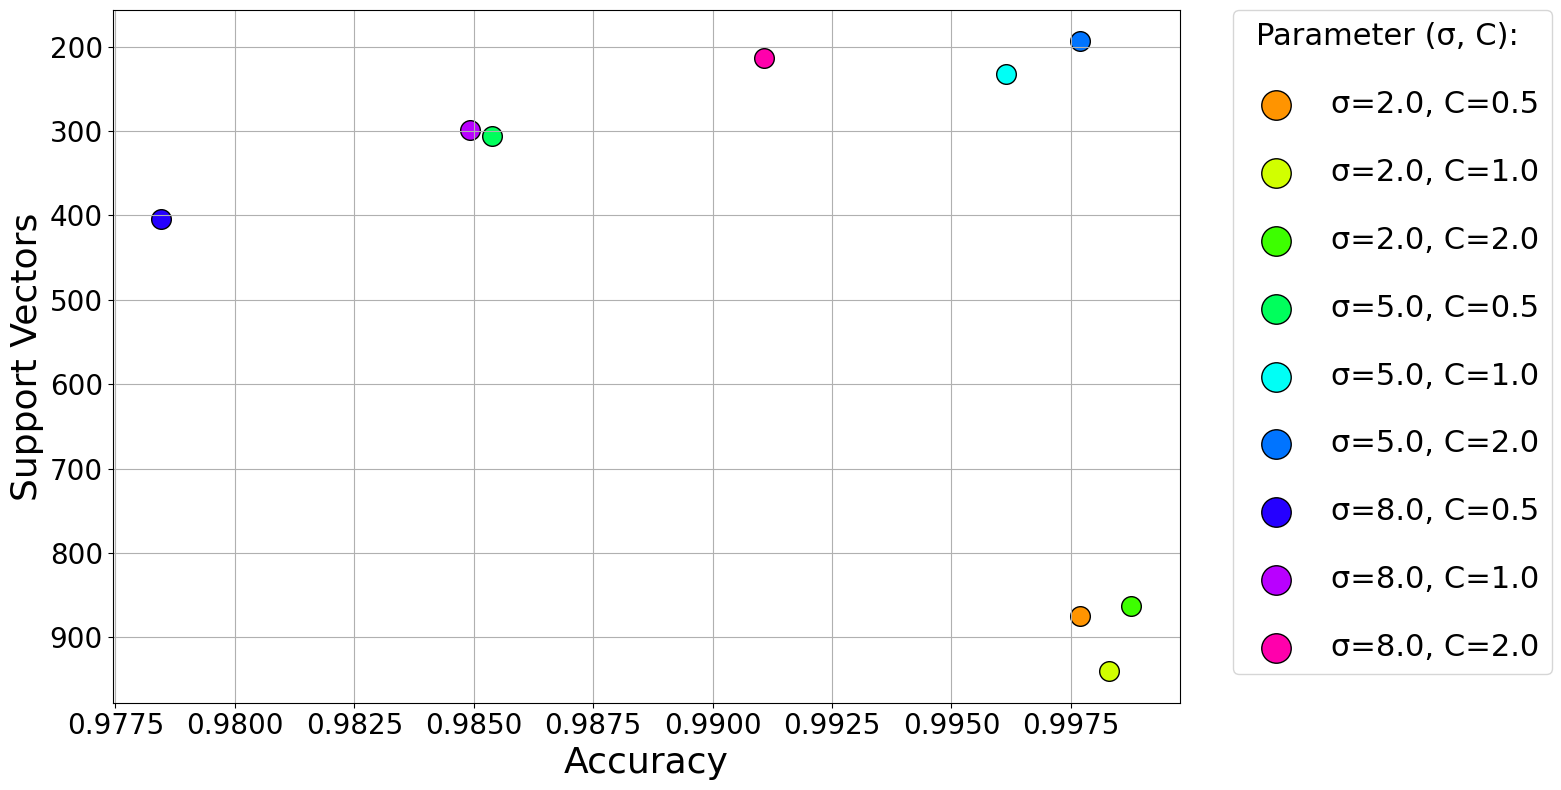

In [6]:
# ===== Study of the kernel RBF parameters =====

features_df = X_one_hot

# Add thr label column
features = features_df.copy()
features['class'] = y.values
    
# Split dataset
X, Y, X_train, Y_train, X_test, Y_test = train_test_split(
    features, training_data_fraction=0.2, class_column_name='class')

results = []

# Convert training data to float 
X_train_floats = X_train.astype(float)
X_test_floats = X_test.astype(float)    

for sigma_test in [2.0, 5.0, 8.0]:
    for c in [0.5, 1.0, 2.0]:
        rbf_svm = BinaryKernelSVM(kernel='rbf', sigma=sigma_test, C=c)
        rbf_svm.fit(X_train_floats, Y_train)
        acc = accuracy_score(Y_test, rbf_svm(X_test))
        n_sv = len(rbf_svm.sv_y)

        # Save to results list
        results.append({
            'Sigma': sigma_test,
            'C': c,
            'Support Vectors': n_sv,
            'Accuracy': acc
        })

# Create a dataframe with results

df_results = pd.DataFrame(results)
df_results['param_combo'] = df_results.apply(lambda row: f"σ={row['Sigma']}, C={row['C']}", axis=1)

unique_combos = df_results['param_combo'].unique()
palette = sns.color_palette("hsv", len(unique_combos))  
color_map = dict(zip(unique_combos, palette))

# Plot each pair of (sigma; C) and performance of their corresponding model

plt.figure(figsize=(12,8))  

for combo in unique_combos:
    subset = df_results[df_results['param_combo'] == combo]
    plt.scatter(subset['Accuracy'], subset['Support Vectors'],
                s=200, color=color_map[combo], edgecolors='k', label=combo)

plt.xlabel("Accuracy", fontsize=26)
plt.ylabel("Support Vectors", fontsize=26)
plt.gca().invert_yaxis()
plt.grid(True)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()

# Legend
plt.legend(title="Parameter (σ, C): ", fontsize=22, title_fontsize=22,
           bbox_to_anchor=(1.05, 1), loc='upper left', 
           borderaxespad=0., labelspacing=1.272, markerscale=1.5)   
plt.show()